# Benchmark v5 — CPU — HIV — scaffold split, seed 4

**Task:** Binary — inhibits HIV replication (1) or not (0)
**Size:** ~41,000 molecules
**Metric:** ROC-AUC ↑
**Cluster GPU strongly recommended** for GNN/LSTM cells.
**Requires:** `./data/hiv_conformers_n25.pkl` for 3D models.

**Scaffold split** (80/10/10), seed **4**. Tabular HPO on train; metrics on the held-out test set.

Results go to `results/seed_4/scaffold/`.


In [1]:
# NOTE: autoreload is intentionally NOT enabled. With C-extension packages
# (numpy, torch, torch_geometric) `%autoreload 2` reloads them mid-run and
# corrupts their state (numpy RecursionError / torch_geometric circular
# import). If you edit the benchmark modules, restart the kernel instead.
import os
# Avoid XGBoost/OpenMP segfaults in Jupyter on macOS (OMP Error #179).
for _omp_var in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[_omp_var] = "1"

import sys
from pathlib import Path

ROOT = Path(".").resolve()
for _ in range(6):
    if (ROOT / "mol_repr_utils.py").exists():
        break
    ROOT = ROOT.parent
else:
    raise FileNotFoundError("Could not find benchmark_v5 root (mol_repr_utils.py)")
sys.path.insert(0, str(ROOT))

from mol_repr_utils import *
from split_utils import (
    get_or_create_splits, subset_array, subset_list, subset_graphs_by_valid_idx,
    check_split_proportions,
)
from conformer_generation import load_conformer_graphs
from hpo_utils import (
    hpo_tabular, hpo_gnn, hpo_schnet, hpo_lstm,
    save_hpo_params, hpo_params_path,
)
from hpo_config import SKLEARN_HPO_N_ITER

DATA_DIR = ROOT / "data"

DEVICE = get_device()
print(f"Benchmark v5 (CPU) code root: {ROOT}")
print(f"Device: {DEVICE}")
print("Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.")


INFO | Using device: cpu (request a GPU node on the cluster for large GNN/LSTM jobs)


Benchmark v5 (CPU) code root: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5
Device: cpu
Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.


In [2]:
DATASET_SLUG = "hiv"
TASK_TYPE = "classification"
OUT_CHANNELS = 1
BATCH_SIZE = 128
GNN_EPOCHS = 80
LSTM_EPOCHS = 60
TOX21_TABULAR = False

SPLIT_MODE = "scaffold"   # "scaffold" or "random"
SPLIT_SEED = 4

RESULTS_ROOT = ROOT / "results" / f"seed_{SPLIT_SEED}" / SPLIT_MODE
RESULTS_DIR = RESULTS_ROOT / "cpu"
SPLITS_DIR = RESULTS_ROOT / "splits"
HPO_DIR = RESULTS_DIR / "hpo"
HISTORY_DIR = RESULTS_DIR / "histories"
for d in (RESULTS_DIR, SPLITS_DIR, HPO_DIR, HISTORY_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f"Results → {RESULTS_ROOT}")

PARTIAL_PATH = RESULTS_DIR / f"{DATASET_SLUG}_partial.json"
FRESH_RUN = False
HPO_N_ITER = SKLEARN_HPO_N_ITER

if FRESH_RUN:
    reset_dataset_run(
        DATASET_SLUG, RESULTS_DIR,
        results_root=RESULTS_ROOT, split_mode=SPLIT_MODE,
    )
    print("Fresh run — cleared partial results and splits.")

results = load_partial_results(PARTIAL_PATH)
if results:
    print(f"Resuming {len(results)} saved model(s): {', '.join(order_results(results).keys())}")
print(f"SPLIT_SEED={SPLIT_SEED}  mode={SPLIT_MODE}")


Results → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/scaffold
SPLIT_SEED=4  mode=scaffold


### Load data


In [3]:
import numpy as np
import pandas as pd

df = load_dataset("hiv", cache_dir=DATA_DIR)
smiles, y = preprocess_dataset(df, "hiv")
print(f"Molecules : {len(smiles)}")
print(f"Class balance: {np.bincount(y.astype(int))}  (pos rate: {y.mean():.1%})")
smiles, y = filter_bonded_molecules(smiles, y)
print(f'After bond filter: {len(smiles)} molecules')


INFO | Loading 'hiv' from cache: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/hiv.csv
[22:14:21] Explicit valence for atom # 3 Al, 6, is greater than permitted
[22:14:21] Explicit valence for atom # 5 B, 5, is greater than permitted
[22:14:24] Explicit valence for atom # 16 Al, 9, is greater than permitted
[22:14:25] Explicit valence for atom # 4 Al, 9, is greater than permitted
[22:14:27] Explicit valence for atom # 12 Al, 7, is greater than permitted
[22:14:27] Explicit valence for atom # 13 Al, 7, is greater than permitted
[22:14:28] WARNING: not removing hydrogen atom without neighbors
[22:14:28] WARNING: not removing hydrogen atom without neighbors
[22:14:28] Explicit valence for atom # 6 Ge, 5, is greater than permitted
INFO | [hiv] 41120 / 41127 valid molecules
[22:14:57] WARNING: not removing hydrogen atom without neighbors
[22:14:57] WARNING: not removing hydrogen atom without neighbors


Molecules : 41120
Class balance: [39677  1443]  (pos rate: 3.5%)


[22:15:07] WARNING: not removing hydrogen atom without neighbors
[22:15:07] WARNING: not removing hydrogen atom without neighbors


After bond filter: 41120 molecules


### Scaffold split


In [4]:
split_data = get_or_create_splits(
    smiles, RESULTS_ROOT, DATASET_SLUG,
    mode=SPLIT_MODE, seed=SPLIT_SEED, force=FRESH_RUN,
)
train_idx = split_data["train_idx"]
val_idx = split_data["val_idx"]
test_idx = split_data["test_idx"]
# Guard: v4's malformed-split failure mode can never pass silently now.
check_split_proportions(train_idx, val_idx, test_idx, raise_on_fail=True)
print(split_data["summary"])


[22:15:25] WARNING: not removing hydrogen atom without neighbors
[22:15:25] WARNING: not removing hydrogen atom without neighbors
[22:15:44] WARNING: not removing hydrogen atom without neighbors
[22:15:44] WARNING: not removing hydrogen atom without neighbors
[22:15:56] WARNING: not removing hydrogen atom without neighbors
[22:15:56] WARNING: not removing hydrogen atom without neighbors
INFO | Saved scaffold split → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/scaffold/splits/hiv_scaffold_splits.pkl (train=32896, val=4112, test=4112, scaffolds=19082)


{'n_total': 41120, 'n_train': 32896, 'n_val': 4112, 'n_test': 4112, 'n_scaffolds_total': 19082, 'n_scaffolds_train': 10858, 'n_scaffolds_val': 4112, 'n_scaffolds_test': 4112}


### Representations


In [5]:
X_morgan = smiles_to_morgan(smiles)
X_desc = smiles_to_descriptors(smiles)
X_combined = smiles_to_combined(smiles)
print(X_morgan.shape, X_desc.shape, X_combined.shape)


[22:16:14] WARNING: not removing hydrogen atom without neighbors
[22:16:14] WARNING: not removing hydrogen atom without neighbors
[22:28:20] WARNING: not removing hydrogen atom without neighbors
[22:28:20] WARNING: not removing hydrogen atom without neighbors
[22:28:20] WARNING: not removing hydrogen atom without neighbors
[22:28:20] WARNING: not removing hydrogen atom without neighbors
[22:30:27] WARNING: not removing hydrogen atom without neighbors
[22:30:27] WARNING: not removing hydrogen atom without neighbors
[22:42:50] WARNING: not removing hydrogen atom without neighbors
[22:42:50] WARNING: not removing hydrogen atom without neighbors
[22:42:50] WARNING: not removing hydrogen atom without neighbors
[22:42:50] WARNING: not removing hydrogen atom without neighbors


(41120, 2048) (41120, 217) (41120, 2265)


### Morgan + RF


In [6]:
MODEL_KEY = "Morgan + RF"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_morgan, train_idx)
    X_te = subset_array(X_morgan, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="rf",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


→ Morgan + RF (HPO on train=32896, test=4112) …


INFO | Saved Morgan + RF → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/scaffold/cpu/hiv_partial.json


   best params: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 3, 'n_estimators': 286}
   test metrics: {'ROC-AUC': (0.7750275412078826, 0.0), 'PRC-AUC': (0.38593331908782535, 0.0)}


### Morgan + SVM


In [7]:
MODEL_KEY = "Morgan + SVM"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_morgan, train_idx)
    X_te = subset_array(X_morgan, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="svm",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


INFO | SVM HPO subsample: 2000 / 32896 train molecules


→ Morgan + SVM (HPO on train=32896, test=4112) …


INFO | Saved Morgan + SVM → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/scaffold/cpu/hiv_partial.json


   best params: {'C': 2.8190407729558355, 'gamma': 'scale'}
   test metrics: {'ROC-AUC': (0.7583346403203283, 0.0), 'PRC-AUC': (0.37301150721777304, 0.0)}


### Morgan + XGBoost


In [8]:
MODEL_KEY = "Morgan + XGBoost"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_morgan, train_idx)
    X_te = subset_array(X_morgan, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="xgb",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


→ Morgan + XGBoost (HPO on train=32896, test=4112) …


INFO | Saved Morgan + XGBoost → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/scaffold/cpu/hiv_partial.json


   best params: {'colsample_bytree': 0.8795924115052465, 'learning_rate': 0.045546723202788617, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 167, 'subsample': 0.6981814834332408}
   test metrics: {'ROC-AUC': (0.7599143624328477, 0.0), 'PRC-AUC': (0.4030330657652616, 0.0)}


### Descriptors + RF


In [9]:
MODEL_KEY = "Descriptors + RF"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_desc, train_idx)
    X_te = subset_array(X_desc, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="rf",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


→ Descriptors + RF (HPO on train=32896, test=4112) …


INFO | Saved Descriptors + RF → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/scaffold/cpu/hiv_partial.json


   best params: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'n_estimators': 121}
   test metrics: {'ROC-AUC': (0.7740487181764413, 0.0), 'PRC-AUC': (0.3477402767489221, 0.0)}


### Descriptors + SVM


In [10]:
MODEL_KEY = "Descriptors + SVM"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_desc, train_idx)
    X_te = subset_array(X_desc, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="svm",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


INFO | SVM HPO subsample: 2000 / 32896 train molecules


→ Descriptors + SVM (HPO on train=32896, test=4112) …


INFO | Saved Descriptors + SVM → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/scaffold/cpu/hiv_partial.json


   best params: {'C': 2.450957472632911, 'gamma': 'scale'}
   test metrics: {'ROC-AUC': (0.7512750209275387, 0.0), 'PRC-AUC': (0.33281069003388997, 0.0)}


### Descriptors + XGBoost


In [11]:
MODEL_KEY = "Descriptors + XGBoost"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_desc, train_idx)
    X_te = subset_array(X_desc, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="xgb",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


→ Descriptors + XGBoost (HPO on train=32896, test=4112) …


INFO | Saved Descriptors + XGBoost → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/scaffold/cpu/hiv_partial.json


   best params: {'colsample_bytree': 0.7633775440608059, 'learning_rate': 0.020309263159157747, 'max_depth': 10, 'min_child_weight': 3, 'n_estimators': 245, 'subsample': 0.7043888303881687}
   test metrics: {'ROC-AUC': (0.7939407453038223, 0.0), 'PRC-AUC': (0.39503563579722045, 0.0)}


### Combined + XGBoost


In [12]:
MODEL_KEY = "Combined + XGBoost"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY} — already in {PARTIAL_PATH}")
else:
    X_tr = subset_array(X_combined, train_idx)
    X_te = subset_array(X_combined, test_idx)
    y_tr = subset_array(y, train_idx)
    y_te = subset_array(y, test_idx)
    print(f"→ {MODEL_KEY} (HPO on train={len(train_idx)}, test={len(test_idx)}) …")
    best, metrics = hpo_tabular(
        X_tr, y_tr, TASK_TYPE, model_kind="xgb",
        tox21=False, n_iter=HPO_N_ITER, seed=SPLIT_SEED,
        X_test=X_te, y_test=y_te,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH)
    print(f"   best params: {best}")
    print(f"   test metrics: {metrics}")


→ Combined + XGBoost (HPO on train=32896, test=4112) …


INFO | Saved Combined + XGBoost → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/scaffold/cpu/hiv_partial.json


   best params: {'colsample_bytree': 0.7633775440608059, 'learning_rate': 0.020309263159157747, 'max_depth': 10, 'min_child_weight': 3, 'n_estimators': 245, 'subsample': 0.7043888303881687}
   test metrics: {'ROC-AUC': (0.8034493118949673, 0.0), 'PRC-AUC': (0.418628156156363, 0.0)}


### Finalize CPU track


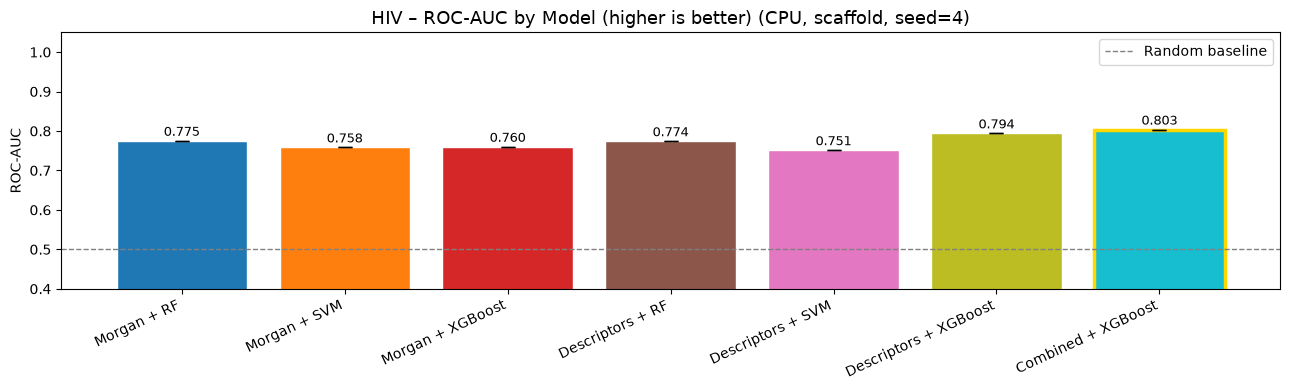

=== HIV Results (7/12 models) ===
                               ROC-AUC          PRC-AUC
Model                                                  
Morgan + RF            0.7750 ± 0.0000  0.3859 ± 0.0000
Morgan + SVM           0.7583 ± 0.0000  0.3730 ± 0.0000
Morgan + XGBoost       0.7599 ± 0.0000  0.4030 ± 0.0000
Descriptors + RF       0.7740 ± 0.0000  0.3477 ± 0.0000
Descriptors + SVM      0.7513 ± 0.0000  0.3328 ± 0.0000
Descriptors + XGBoost  0.7939 ± 0.0000  0.3950 ± 0.0000
Combined + XGBoost     0.8034 ± 0.0000  0.4186 ± 0.0000

Final CSV : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/scaffold/cpu/hiv_results.csv
Plot      : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_4/scaffold/cpu/hiv_auc_comparison.png
Partial   : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_

,ROC-AUC,PRC-AUC
Model,,
Morgan + RF,0.7750 ± 0.0000,0.3859 ± 0.0000
Morgan + SVM,0.7583 ± 0.0000,0.3730 ± 0.0000
Morgan + XGBoost,0.7599 ± 0.0000,0.4030 ± 0.0000
Descriptors + RF,0.7740 ± 0.0000,0.3477 ± 0.0000
Descriptors + SVM,0.7513 ± 0.0000,0.3328 ± 0.0000
Descriptors + XGBoost,0.7939 ± 0.0000,0.3950 ± 0.0000
Combined + XGBoost,0.8034 ± 0.0000,0.4186 ± 0.0000


In [13]:
finalize_dataset_results(DATASET_SLUG, PARTIAL_PATH, RESULTS_DIR, TASK_TYPE, plot_title=f"HIV – ROC-AUC by Model (higher is better) (CPU, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="ROC-AUC", minimize=False)
